In [1]:
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from pathlib import Path
from sklearn.decomposition import PCA

from pea_met_network.qa_qc import coverage_summary
from pea_met_network.redundancy import (
    benchmark_to_stanhope,
    build_station_matrix,
    build_station_recommendations,
    cluster_station_order,
    pairwise_station_correlation,
    pca_station_loadings,
)

# ---------------------------------------------------------------------------
# FWI mode selector — switch between "hourly" and "compliant"
# ---------------------------------------------------------------------------
FWI_MODE = "hourly"

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path(".").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "notebooks" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Date range for analysis — must match cleaning-config.json
ANALYSIS_START = pd.Timestamp("2023-04-01", tz="UTC")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

print(f"FWI mode: {FWI_MODE}")
print(f"Processed dir: {PROCESSED_DIR}")


FWI mode: hourly
Processed dir: /mnt/fast_data/workspaces/pea-met-network/data/processed


## 1. Data Loading

Load hourly processed data for all stations. Station list is derived from disk.

In [2]:
# Discover stations from disk — no hardcoded list
stations = sorted([
    d.name for d in PROCESSED_DIR.iterdir()
    if d.is_dir() and (d / "station_hourly.csv").exists()
])
print(f"Stations found: {stations}")

hourly_frames = []
daily_frames = []
for station in stations:
    h_path = PROCESSED_DIR / station / "station_hourly.csv"
    d_path = PROCESSED_DIR / station / "station_daily.csv"
    h_df = pd.read_csv(h_path, parse_dates=["timestamp_utc"])
    h_df["timestamp_utc"] = pd.to_datetime(h_df["timestamp_utc"], utc=True)
    h_df = h_df[h_df["timestamp_utc"] >= ANALYSIS_START]
    hourly_frames.append(h_df)
    if d_path.exists():
        d_df = pd.read_csv(d_path, parse_dates=["timestamp_utc"])
        d_df["timestamp_utc"] = pd.to_datetime(d_df["timestamp_utc"], utc=True)
        daily_frames.append(d_df)
    tmin = h_df["timestamp_utc"].min()
    tmax = h_df["timestamp_utc"].max()
    print(f"  {station}: {len(h_df)} hourly rows  ({tmin} to {tmax})")

hourly_all = pd.concat(hourly_frames, ignore_index=True)
if daily_frames:
    daily_all = pd.concat(daily_frames, ignore_index=True)
else:
    daily_all = pd.DataFrame()
n = hourly_all["station"].nunique()
print(f"\nCombined: {len(hourly_all)} hourly rows, {n} stations")


Stations found: ['cavendish', 'greenwich', 'north_rustico', 'stanhope', 'stanley_bridge', 'tracadie']
  cavendish: 26092 hourly rows  (2023-04-01 00:00:00+00:00 to 2026-03-23 03:00:00+00:00)


  greenwich: 26092 hourly rows  (2023-04-01 00:00:00+00:00 to 2026-03-23 03:00:00+00:00)
  north_rustico: 26113 hourly rows  (2023-04-01 00:00:00+00:00 to 2026-03-24 00:00:00+00:00)


  stanhope: 24144 hourly rows  (2023-04-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00)
  stanley_bridge: 26092 hourly rows  (2023-04-01 00:00:00+00:00 to 2026-03-23 03:00:00+00:00)


  tracadie: 23956 hourly rows  (2023-06-29 00:00:00+00:00 to 2026-03-23 03:00:00+00:00)

Combined: 152489 hourly rows, 6 stations


## 2. Exploratory Data Analysis

### 2.1 Station Coverage Table

Summary of temporal coverage per station.


In [3]:
coverage_frames = []
for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath, parse_dates=["timestamp_utc"])
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df[df["timestamp_utc"] >= ANALYSIS_START]
    coverage_frames.append(df[["station", "timestamp_utc"]])

coverage_df = pd.concat(coverage_frames, ignore_index=True)
cov_summary = coverage_summary(coverage_df)
print(cov_summary.to_string(index=False))


       station  total_records
     cavendish          26092
     greenwich          26092
 north_rustico          26113
      stanhope          24144
stanley_bridge          26092
      tracadie          23956


### 2.2 Temporal Coverage Summary

Visual overview of data availability by station over time.


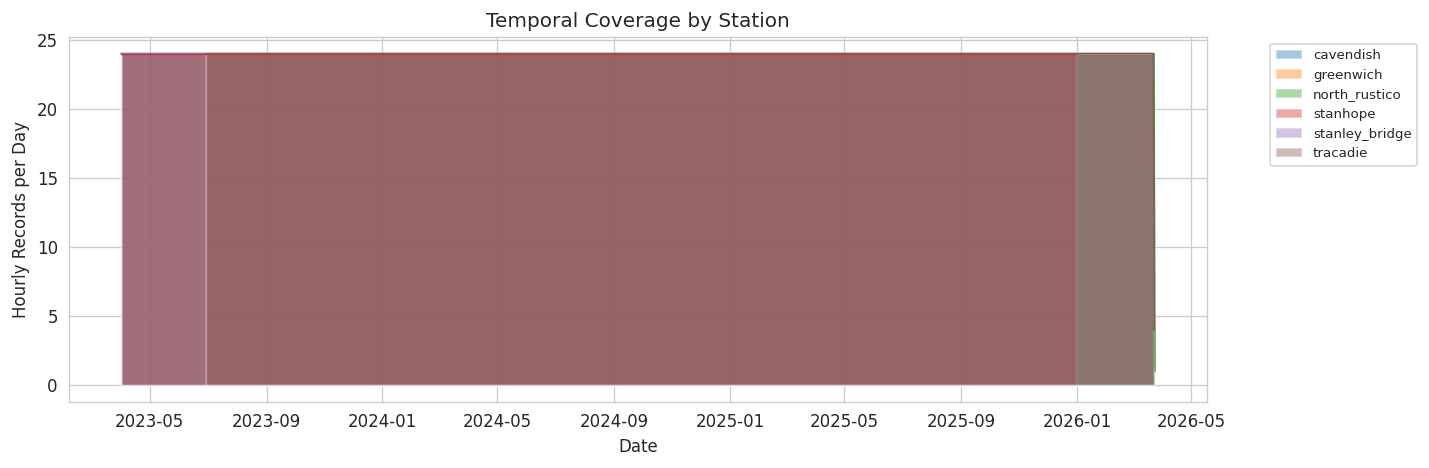

Saved: notebooks/figures/temporal_coverage.png


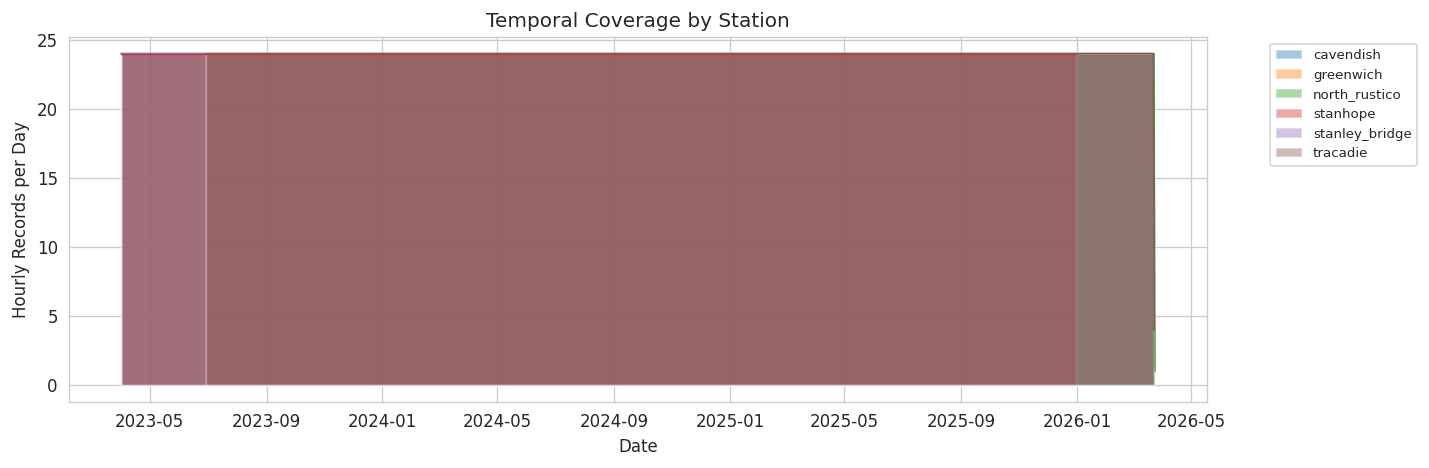

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))

for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath, parse_dates=["timestamp_utc"])
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df[df["timestamp_utc"] >= ANALYSIS_START]
    start = df["timestamp_utc"].min().floor("D")
    end = df["timestamp_utc"].max().floor("D")
    date_range = pd.date_range(start, end, freq="D")
    daily_counts = df.set_index("timestamp_utc").resample("D").size()
    daily_counts = daily_counts.reindex(date_range, fill_value=0)
    ax.fill_between(daily_counts.index, 0, daily_counts.values, alpha=0.4, label=station)
    ax.plot(daily_counts.index, daily_counts.values, linewidth=0.8)

ax.set_xlabel("Date")
ax.set_ylabel("Hourly Records per Day")
ax.set_title("Temporal Coverage by Station")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "temporal_coverage.png", bbox_inches="tight")
display(Image(filename=str(FIGURES_DIR / "temporal_coverage.png")))
print("Saved: notebooks/figures/temporal_coverage.png")


### 2.3 Missingness Heatmap

Percentage of missing values per variable per station, including FWI columns.


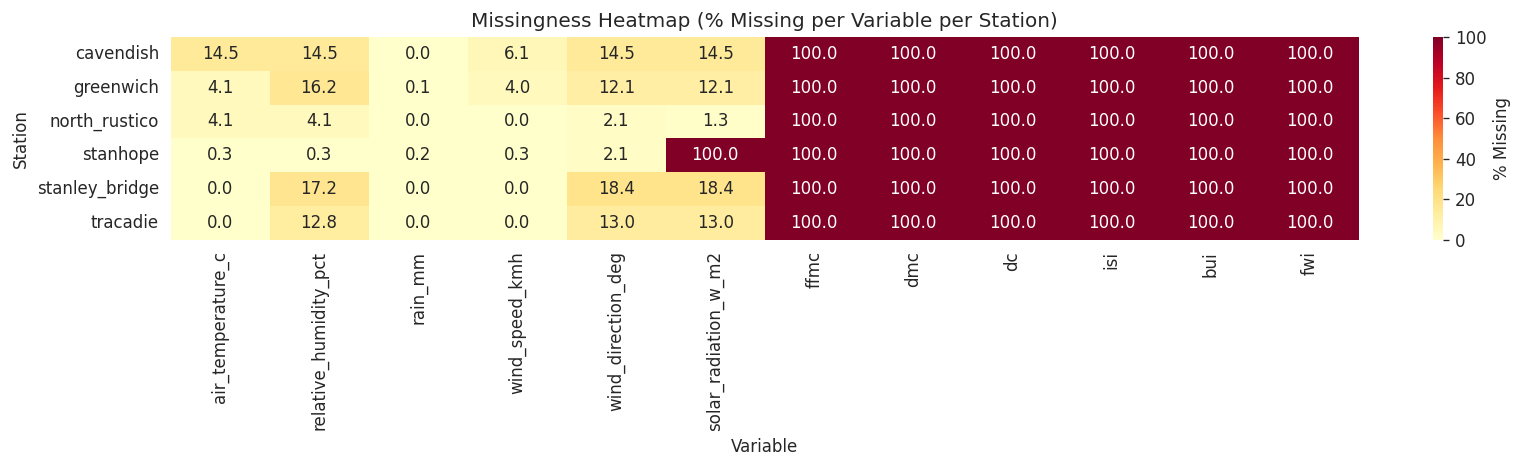

Saved: notebooks/figures/missingness_heatmap.png

Missingness summary:
                air_temperature_c  relative_humidity_pct  rain_mm  wind_speed_kmh  wind_direction_deg  solar_radiation_w_m2   ffmc    dmc     dc    isi    bui    fwi
station                                                                                                                                                              
cavendish                    14.5                   14.5      0.0             6.1                14.5                  14.5  100.0  100.0  100.0  100.0  100.0  100.0
greenwich                     4.1                   16.2      0.1             4.0                12.1                  12.1  100.0  100.0  100.0  100.0  100.0  100.0
north_rustico                 4.1                    4.1      0.0             0.0                 2.1                   1.3  100.0  100.0  100.0  100.0  100.0  100.0
stanhope                      0.3                    0.3      0.2             0.3                 2

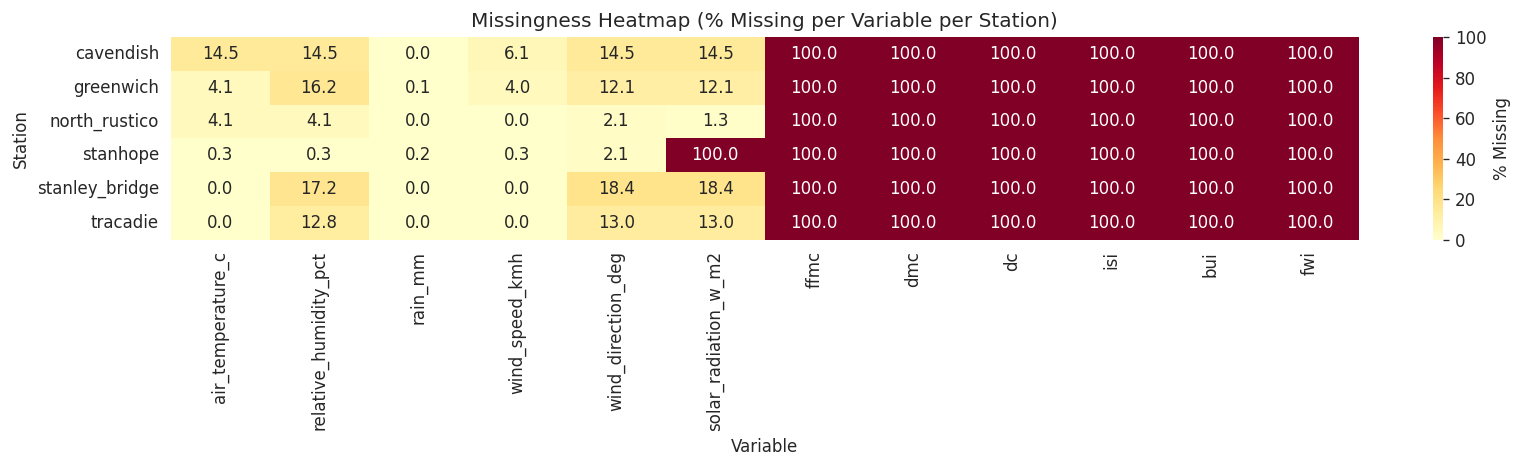

In [5]:
key_vars = [
    "air_temperature_c", "relative_humidity_pct", "rain_mm",
    "wind_speed_kmh", "wind_direction_deg", "solar_radiation_w_m2",
    "ffmc", "dmc", "dc", "isi", "bui", "fwi",
]

missing_frames = []
for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath)
    df = df[pd.to_datetime(df["timestamp_utc"], utc=True) >= ANALYSIS_START]
    row = {"station": station}
    for var in key_vars:
        if var in df.columns:
            row[var] = df[var].isna().mean() * 100
        else:
            row[var] = 100.0
    missing_frames.append(row)

missing_df = pd.DataFrame(missing_frames).set_index("station")
missing_df = missing_df[key_vars]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    missing_df, annot=True, fmt=".1f", cmap="YlOrRd",
    ax=ax, cbar_kws={"label": "% Missing"},
)
ax.set_title("Missingness Heatmap (% Missing per Variable per Station)")
ax.set_xlabel("Variable")
ax.set_ylabel("Station")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "missingness_heatmap.png", bbox_inches="tight")
display(Image(filename=str(FIGURES_DIR / "missingness_heatmap.png")))
print("Saved: notebooks/figures/missingness_heatmap.png")
print("\nMissingness summary:")
print(missing_df.round(1).to_string())


### 2.4 Imputation Summary

Gaps filled per station per variable from the pipeline imputation report.


Imputation report: 717 entries

Gaps filled per station per variable:
variable        air_temperature_c  barometric_pressure_kpa  dew_point_c  relative_humidity_pct  solar_radiation_w_m2  wind_direction_deg  wind_speed_kmh
station                                                                                                                                                 
cavendish                    3789                    26092         3787                   3787                  3786                3786            3890
greenwich                   10158                    26092         4216                   4229                  3147                3145            3249
north_rustico                1076                      330          331                   1075                   331                 547            1188
stanhope                       77                    24144           68                     79                     0                 516              68
stanley_brid

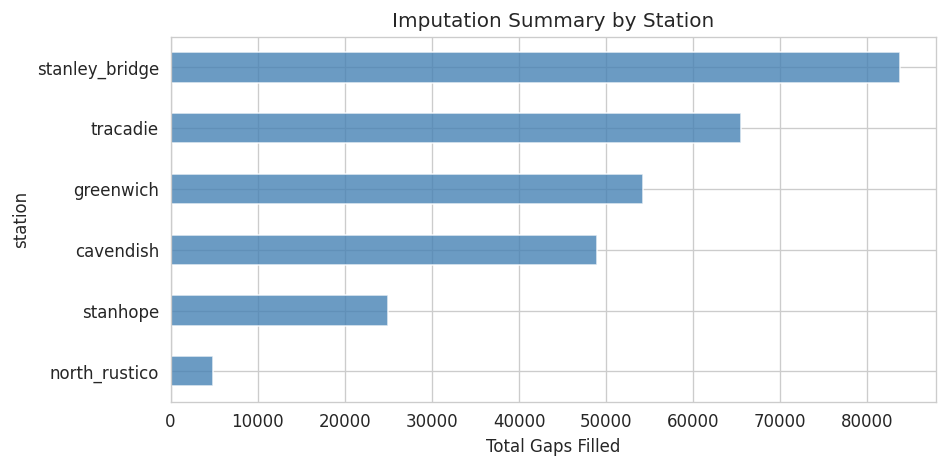

Saved: notebooks/figures/imputation_summary.png


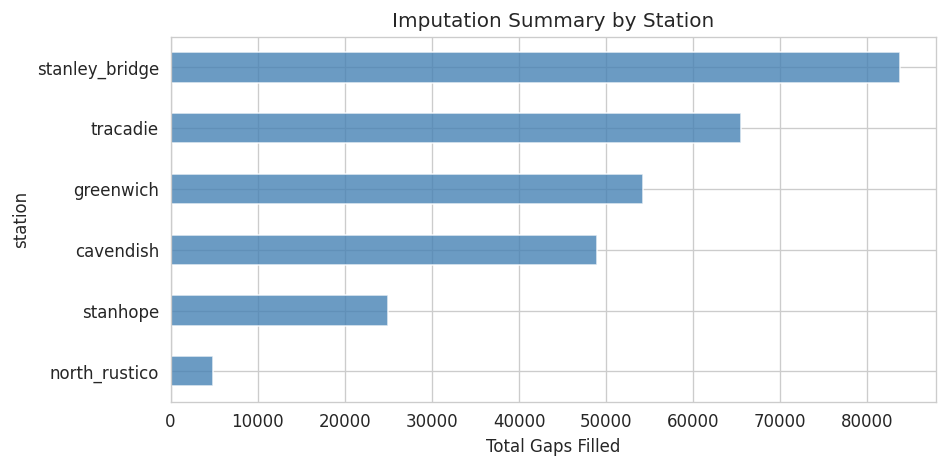

In [6]:
imp_path = PROCESSED_DIR / "imputation_report.csv"
if imp_path.exists():
    imp_df = pd.read_csv(imp_path)
    print(f"Imputation report: {len(imp_df)} entries")
    print("\nGaps filled per station per variable:")
    pivot = imp_df.groupby(["station", "variable"])["count_affected"].sum().reset_index()
    pivot_table = pivot.pivot(index="station", columns="variable", values="count_affected").fillna(0).astype(int)
    print(pivot_table.to_string())

    print("\nImputation method breakdown:")
    method_counts = imp_df["method"].value_counts()
    print(method_counts.to_string())

    # Bar chart: total gaps filled by station
    station_totals = imp_df.groupby("station")["count_affected"].sum().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 4))
    station_totals.plot(kind="barh", ax=ax, color="steelblue", alpha=0.8)
    ax.set_xlabel("Total Gaps Filled")
    ax.set_title("Imputation Summary by Station")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "imputation_summary.png", bbox_inches="tight")
    display(Image(filename=str(FIGURES_DIR / "imputation_summary.png")))
    print("Saved: notebooks/figures/imputation_summary.png")
else:
    print("imputation_report.csv not found — run pipeline first.")


## 3. Fire Weather Index Analysis

Time series of FWI system components for all stations with computed indices.


### 3.1 FWI Component Time Series

Daily-mean FWI components for all stations. FFMC uses hourly values; DMC, DC, BUI, FWI use daily means.


In [7]:
fwi_vars = ["ffmc", "dmc", "dc", "isi", "bui", "fwi"]

fwi_stations = []
for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath, parse_dates=["timestamp_utc"])
    df = df[df["timestamp_utc"] >= ANALYSIS_START]
    if "fwi" in df.columns and df["fwi"].notna().sum() > 100:
        fwi_stations.append(station)

print(f"Stations with FWI data: {fwi_stations}")

if fwi_stations:
    fig, axes = plt.subplots(len(fwi_stations), 1, figsize=(14, 3 * len(fwi_stations)), sharex=True)
    if len(fwi_stations) == 1:
        axes = [axes]

    for idx, station in enumerate(fwi_stations):
        fpath = PROCESSED_DIR / station / "station_hourly.csv"
        df = pd.read_csv(fpath, parse_dates=["timestamp_utc"])
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
        df = df[df["timestamp_utc"] >= ANALYSIS_START]
        df_daily = df.set_index("timestamp_utc")[fwi_vars].resample("D").mean()
        ax = axes[idx]
        for var in fwi_vars:
            if var in df_daily.columns:
                ax.plot(df_daily.index, df_daily[var], label=var, alpha=0.8, linewidth=0.9)
        ax.set_ylabel("Value")
        ax.set_title(f"FWI Components - {station}")
        ax.legend(fontsize=7, ncol=3)

    axes[-1].set_xlabel("Date")
    fig.suptitle("Fire Weather Index Time Series (Daily Means)", y=1.02)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "fwi_timeseries.png", bbox_inches="tight")
    display(Image(filename=str(FIGURES_DIR / "fwi_timeseries.png")))
    print(f"Plotted FWI for: {fwi_stations}")
    print("Saved: notebooks/figures/fwi_timeseries.png")
else:
    print("FWI analysis skipped: no stations with non-missing FWI data")


Stations with FWI data: []
FWI analysis skipped: no stations with non-missing FWI data


### 3.2 FWI Mode Comparison

Overlay FWI values from hourly and compliant modes to show divergence (e.g., during chain breaks).


In [8]:
# Try to load both modes for comparison
hourly_fwi_data = {}
compliant_fwi_data = {}

for station in stations:
    h_path = PROCESSED_DIR / station / "station_hourly.csv"
    d_path = PROCESSED_DIR / station / "station_daily.csv"
    c_path = PROCESSED_DIR / station / f"{station}_daily_compliant.csv"

    if h_path.exists():
        df = pd.read_csv(h_path, parse_dates=["timestamp_utc"])
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
        df = df[df["timestamp_utc"] >= ANALYSIS_START]
        if "fwi" in df.columns and df["fwi"].notna().sum() > 0:
            hourly_fwi_data[station] = df.set_index("timestamp_utc")["fwi"].resample("D").mean()

    if c_path.exists():
        df_c = pd.read_csv(c_path, parse_dates=["timestamp_utc"])
        df_c["timestamp_utc"] = pd.to_datetime(df_c["timestamp_utc"], utc=True)
        df_c = df_c[df_c["timestamp_utc"] >= ANALYSIS_START]
        if "fwi" in df_c.columns and df_c["fwi"].notna().sum() > 0:
            compliant_fwi_data[station] = df_c.set_index("timestamp_utc")["fwi"]

compare_stations = sorted(set(hourly_fwi_data.keys()) & set(compliant_fwi_data.keys()))

if compare_stations:
    fig, axes = plt.subplots(len(compare_stations), 1, figsize=(14, 3 * len(compare_stations)), sharex=True)
    if len(compare_stations) == 1:
        axes = [axes]

    for idx, station in enumerate(compare_stations):
        ax = axes[idx]
        ax.plot(hourly_fwi_data[station].index, hourly_fwi_data[station].values, label="hourly", alpha=0.7, linewidth=0.9)
        ax.plot(compliant_fwi_data[station].index, compliant_fwi_data[station].values, label="compliant", alpha=0.7, linewidth=0.9)
        ax.set_ylabel("FWI")
        ax.set_title(f"FWI Mode Comparison — {station}")
        ax.legend(fontsize=8)

    axes[-1].set_xlabel("Date")
    fig.suptitle("Hourly vs Compliant FWI", y=1.02)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "fwi_mode_comparison.png", bbox_inches="tight")
    display(Image(filename=str(FIGURES_DIR / "fwi_mode_comparison.png")))
    print(f"Mode comparison for: {compare_stations}")
    print("Saved: notebooks/figures/fwi_mode_comparison.png")
else:
    print("FWI mode comparison skipped: compliant-mode daily files not found.")
    print("Run the pipeline with --fwi-mode compliant to generate them.")


FWI mode comparison skipped: compliant-mode daily files not found.
Run the pipeline with --fwi-mode compliant to generate them.


### 3.3 FWI Value Statistics

Descriptive statistics (min, max, mean, std) for FWI codes per station, sourced from the QA/QC report.


In [9]:
qa_qc_path = PROCESSED_DIR / f"qa_qc_report_{FWI_MODE}.csv"
if qa_qc_path.exists():
    qa_df = pd.read_csv(qa_qc_path)
    fwi_stat_cols = [c for c in qa_df.columns if c.startswith("fwi_stat_")]
    if fwi_stat_cols:
        stat_display = qa_df[["station"] + fwi_stat_cols].copy()
        print("FWI Value Statistics (from QA/QC report):")
        print(stat_display.to_string(index=False))
    else:
        print("QA/QC report exists but has no fwi_stat_ columns.")
        print("Columns available:", list(qa_df.columns))
else:
    print(f"qa_qc_report_{FWI_MODE}.csv not found — run pipeline first.")


QA/QC report exists but has no fwi_stat_ columns.
Columns available: ['station', 'hourly_rows', 'daily_rows', 'date_range_start', 'date_range_end', 'completeness', 'fwi_mode', 'pre_imp_missing_pct_air_temperature_c', 'pre_imp_missing_pct_relative_humidity_pct', 'pre_imp_missing_pct_wind_speed_kmh', 'pre_imp_missing_pct_rain_mm', 'post_imp_missing_pct_air_temperature_c', 'post_imp_missing_pct_air_temperature_c_qf', 'post_imp_missing_pct_barometric_pressure_kpa', 'post_imp_missing_pct_battery_v', 'post_imp_missing_pct_bui', 'post_imp_missing_pct_bui_qf', 'post_imp_missing_pct_dc', 'post_imp_missing_pct_dc_qf', 'post_imp_missing_pct_dew_point_c', 'post_imp_missing_pct_dmc', 'post_imp_missing_pct_dmc_qf', 'post_imp_missing_pct_ffmc', 'post_imp_missing_pct_ffmc_qf', 'post_imp_missing_pct_fwi', 'post_imp_missing_pct_fwi_qf', 'post_imp_missing_pct_isi', 'post_imp_missing_pct_isi_qf', 'post_imp_missing_pct_rain_mm', 'post_imp_missing_pct_rain_mm_qf', 'post_imp_missing_pct_relative_humidity_pct

### 3.4 Chain Break Analysis

Analysis of FWI chain breaks by station and cause, sourced from the chain break diagnostic report.


Chain break report: 74 entries

Breaks per station by cause:
cause           input_missing  startup
station                               
cavendish                  15        2
greenwich                  27        0
north_rustico               7        0
stanhope                    4        2
stanley_bridge              9        0
tracadie                    6        2

Breakdown by missing input:
missing_input
relative_humidity_pct                                       40
air_temperature_c                                           14
air_temperature_c, relative_humidity_pct                    11
air_temperature_c, relative_humidity_pct, wind_speed_kmh     3


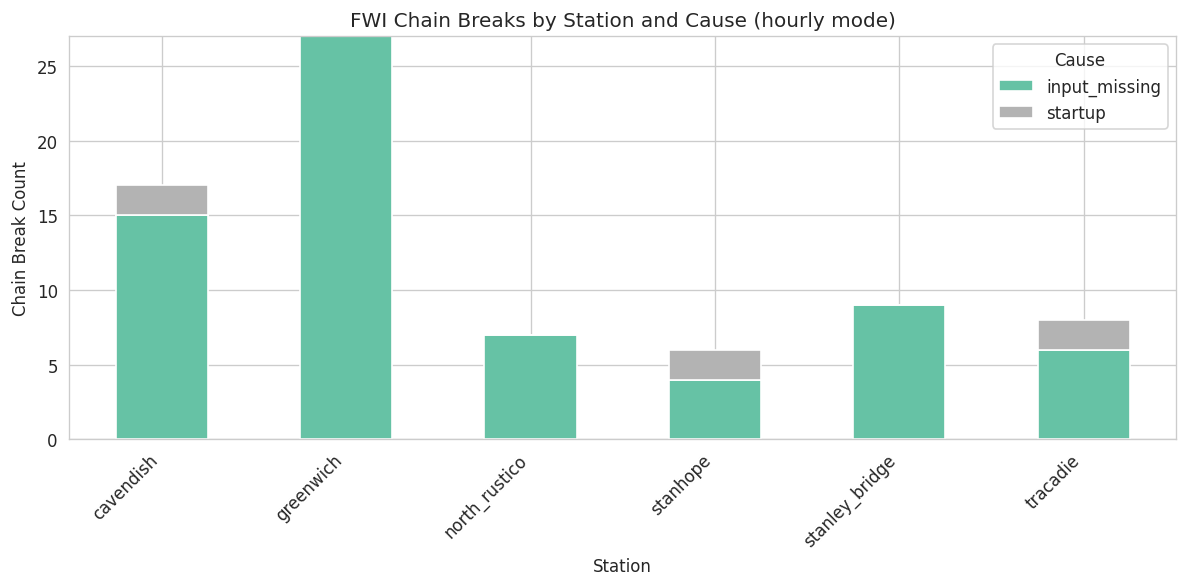

Saved: notebooks/figures/chain_breaks.png


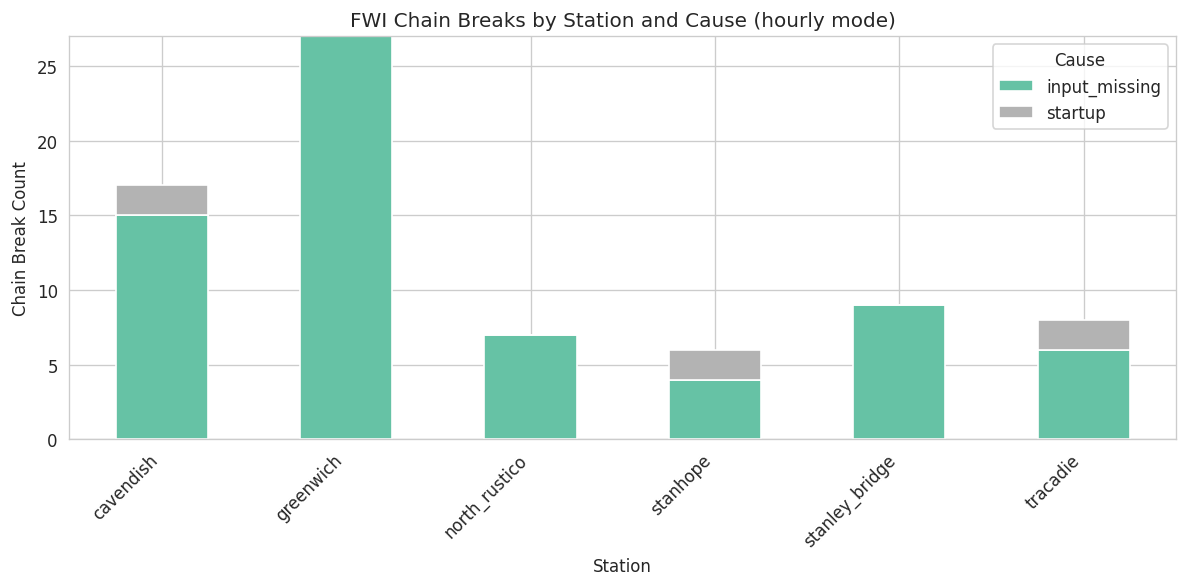

In [10]:
cb_path = PROCESSED_DIR / f"fwi_missingness_report_{FWI_MODE}.csv"
if cb_path.exists():
    cb_df = pd.read_csv(cb_path)
    print(f"Chain break report: {len(cb_df)} entries")

    # Summary table: breaks per station, grouped by cause
    if "cause" in cb_df.columns:
        print("\nBreaks per station by cause:")
        cause_pivot = cb_df.groupby(["station", "cause"]).size().reset_index(name="count")
        cause_table = cause_pivot.pivot(index="station", columns="cause", values="count").fillna(0).astype(int)
        print(cause_table.to_string())

        # Breakdown by missing input
        if "missing_input" in cb_df.columns:
            print("\nBreakdown by missing input:")
            input_counts = cb_df["missing_input"].value_counts()
            print(input_counts.to_string())

        # Bar chart: chain breaks by station, colored by cause
        fig, ax = plt.subplots(figsize=(10, 5))
        causes = cb_df["cause"].unique()
        station_breaks = cb_df.groupby(["station", "cause"]).size().unstack(fill_value=0)
        station_breaks.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
        ax.set_xlabel("Station")
        ax.set_ylabel("Chain Break Count")
        ax.set_title(f"FWI Chain Breaks by Station and Cause ({FWI_MODE} mode)")
        ax.legend(title="Cause")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        fig.savefig(FIGURES_DIR / "chain_breaks.png", bbox_inches="tight")
        display(Image(filename=str(FIGURES_DIR / "chain_breaks.png")))
        print("Saved: notebooks/figures/chain_breaks.png")

        # Cascade origins table
        cascade = cb_df[cb_df["cause"] == "cascade"]
        if len(cascade) > 0 and "cascade_origin" in cascade.columns:
            print("\nCascade origins:")
            print(cascade[["station", "cascade_origin"]].to_string(index=False))
    else:
        print("Chain break report has no 'cause' column. Columns:", list(cb_df.columns))
else:
    print(f"fwi_missingness_report_{FWI_MODE}.csv not found — no chain breaks or pipeline not run.")


## 4. Data Quality Report

Quality metrics from the QA/QC report, quality enforcement actions, and cross-station imputation audit.


### 4.1 Pre/Post Imputation Missingness

Side-by-side comparison of missingness before and after imputation.


In [11]:
qa_qc_path = PROCESSED_DIR / f"qa_qc_report_{FWI_MODE}.csv"
if qa_qc_path.exists():
    qa_df = pd.read_csv(qa_qc_path)
    pre_cols = sorted([c for c in qa_df.columns if c.startswith("pre_imp_missing_pct_")])
    post_cols = sorted([c for c in qa_df.columns if c.startswith("post_imp_missing_pct_")])

    if pre_cols and post_cols:
        # Build comparison for key variables
        comparison_rows = []
        for _, row in qa_df.iterrows():
            station = row["station"]
            for pre_c, post_c in zip(pre_cols, post_cols):
                var = pre_c.replace("pre_imp_missing_pct_", "")
                comparison_rows.append({
                    "station": station,
                    "variable": var,
                    "pre_imputation_%": row[pre_c],
                    "post_imputation_%": row[post_c],
                    "improvement_%": round(row[pre_c] - row[post_c], 2),
                })
        comp_df = pd.DataFrame(comparison_rows)
        print("Pre/Post Imputation Missingness Comparison:")
        print(comp_df.to_string(index=False))
    else:
        print("QA/QC report missing pre/post imputation columns.")
        print("Available columns:", list(qa_df.columns))
else:
    print(f"qa_qc_report_{FWI_MODE}.csv not found.")


Pre/Post Imputation Missingness Comparison:
       station              variable  pre_imputation_%  post_imputation_%  improvement_%
     greenwich     air_temperature_c               0.0             100.00        -100.00
     greenwich               rain_mm               0.0             100.00        -100.00
     greenwich relative_humidity_pct               0.0             100.00        -100.00
     greenwich        wind_speed_kmh               0.0             100.00        -100.00
     cavendish     air_temperature_c               0.0             100.00        -100.00
     cavendish               rain_mm               0.0             100.00        -100.00
     cavendish relative_humidity_pct               0.0             100.00        -100.00
     cavendish        wind_speed_kmh               0.0             100.00        -100.00
 north_rustico     air_temperature_c               0.0             100.00        -100.00
 north_rustico               rain_mm               0.0            

### 4.2 Quality Enforcement Actions

Count of quality enforcement actions by type and station.


In [12]:
qe_path = PROCESSED_DIR / "quality_enforcement_report.csv"
if qe_path.exists():
    qe_df = pd.read_csv(qe_path)
    print(f"Quality enforcement report: {len(qe_df)} actions")

    if "action" in qe_df.columns and "station" in qe_df.columns:
        print("\nActions by type and station:")
        action_pivot = qe_df.groupby(["station", "action"]).size().reset_index(name="count")
        action_table = action_pivot.pivot(index="station", columns="action", values="count").fillna(0).astype(int)
        print(action_table.to_string())
    else:
        print("Columns:", list(qe_df.columns))
else:
    print("quality_enforcement_report.csv not found.")


Quality enforcement report: 5215 actions

Actions by type and station:
action          flag_only  set_nan
station                           
cavendish             126       12
greenwich            1161      607
north_rustico        2559       87
stanhope              315       66
stanley_bridge         56        1
tracadie              136       89


### 4.3 Out-of-Range Summary

Out-of-range counts for temperature, RH, and wind per station from the QA/QC report.


In [13]:
qa_qc_path = PROCESSED_DIR / f"qa_qc_report_{FWI_MODE}.csv"
if qa_qc_path.exists():
    qa_df = pd.read_csv(qa_qc_path)
    oor_cols = [c for c in qa_df.columns if "out_of_range" in c.lower()]
    if oor_cols:
        print("Out-of-Range Summary:")
        print(qa_df[["station"] + oor_cols].to_string(index=False))
    else:
        print("No out-of-range columns in QA/QC report.")
else:
    print(f"qa_qc_report_{FWI_MODE}.csv not found.")


Out-of-Range Summary:
       station  out_of_range_temp_count  out_of_range_rh_count  out_of_range_wind_count  out_of_range_pre_enforcement  out_of_range_post_enforcement
     greenwich                        0                      0                        0                             0                              0
     cavendish                        0                      0                        0                             0                              0
 north_rustico                        0                      0                        0                             0                              0
stanley_bridge                        0                      0                        0                             0                              0
      tracadie                        0                      0                        0                             0                              0
      stanhope                        0                      0                      

### 4.4 Cross-Station Imputation Audit

Donor-to-recipient imputation pairs and counts.


In [14]:
cs_path = PROCESSED_DIR / "cross_station_imputation_audit.csv"
if cs_path.exists():
    cs_df = pd.read_csv(cs_path)
    print(f"Cross-station imputation audit: {len(cs_df)} entries")

    if "donor" in cs_df.columns and "target" in cs_df.columns:
        print("\nDonor -> Recipient pairs:")
        pairs = cs_df.groupby(["donor", "target"]).size().reset_index(name="count")
        print(pairs.to_string(index=False))
    else:
        print("Columns:", list(cs_df.columns))
else:
    print("cross_station_imputation_audit.csv not found.")


Cross-station imputation audit: 77038 entries
Columns: ['station', 'timestamp_utc', 'variable', 'imputed_value', 'quality_flag', 'source', 'method', 'donor_priority']


## 5. Principal Component Analysis

PCA on hourly temperature to identify station similarity patterns.


In [15]:
temp_frames = []
for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath, parse_dates=["timestamp_utc"])
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df[df["timestamp_utc"] >= ANALYSIS_START]
    if "air_temperature_c" in df.columns:
        temp_frames.append(df[["station", "timestamp_utc", "air_temperature_c"]])

temp_all = pd.concat(temp_frames, ignore_index=True)
matrix = build_station_matrix(temp_all, value_column="air_temperature_c")
print(f"Station matrix shape: {matrix.shape}")
print(f"Stations: {list(matrix.columns)}")


Station matrix shape: (26113, 6)
Stations: ['cavendish', 'greenwich', 'north_rustico', 'stanhope', 'stanley_bridge', 'tracadie']


In [16]:
loadings = pca_station_loadings(matrix)
print("PCA Loadings:")
print(loadings.to_string(index=False))


PCA Loadings:
       station component   loading  explained_variance_ratio
     cavendish       PC1  0.413668                  0.963466
     greenwich       PC1  0.396266                  0.963466
 north_rustico       PC1  0.413277                  0.963466
      stanhope       PC1  0.406986                  0.963466
stanley_bridge       PC1  0.405674                  0.963466
      tracadie       PC1  0.413334                  0.963466
     cavendish       PC2 -0.167839                  0.018571
     greenwich       PC2  0.900793                  0.018571
 north_rustico       PC2 -0.171177                  0.018571
      stanhope       PC2 -0.054382                  0.018571
stanley_bridge       PC2 -0.323366                  0.018571
      tracadie       PC2 -0.153547                  0.018571


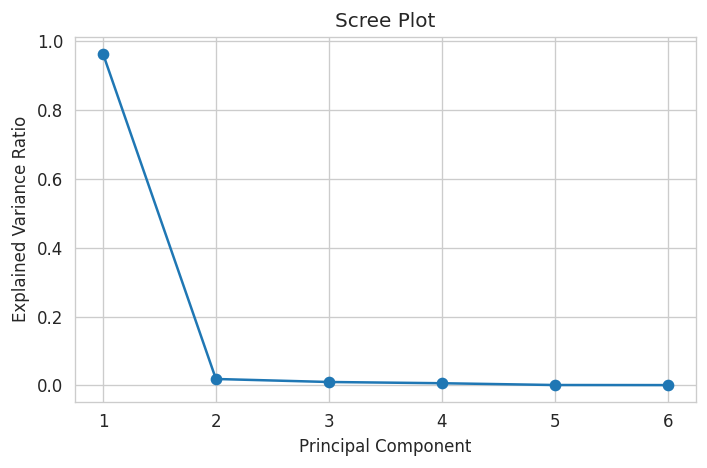

Saved: notebooks/figures/pca_scree.png
Explained variance ratios: [0.9635, 0.0186, 0.0098, 0.0062, 0.0011, 0.0008]


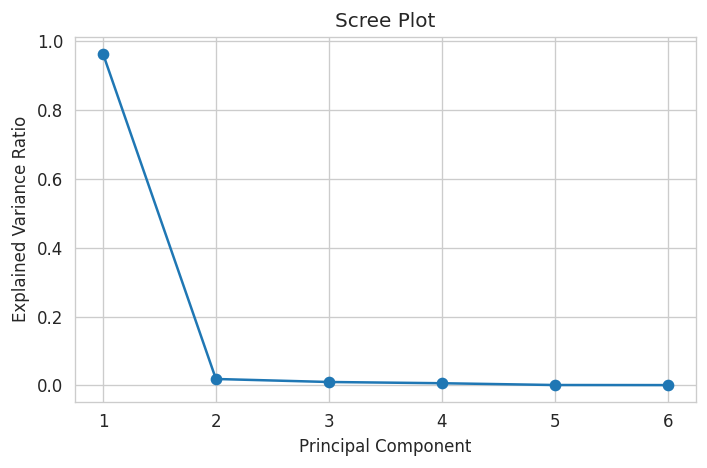

In [17]:
normalized = matrix.dropna(axis="index", how="any")
normalized = (normalized - normalized.mean()) / normalized.std()

n_comp = min(len(matrix.columns), normalized.shape[0])
pca_full = PCA(n_components=n_comp)
pca_full.fit(normalized)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, n_comp + 1), pca_full.explained_variance_ratio_, "o-")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("Scree Plot")
ax.set_xticks(range(1, n_comp + 1))
plt.tight_layout()
fig.savefig(FIGURES_DIR / "pca_scree.png", bbox_inches="tight")
display(Image(filename=str(FIGURES_DIR / "pca_scree.png")))
print("Saved: notebooks/figures/pca_scree.png")
ratios = pca_full.explained_variance_ratio_.round(4).tolist()
print(f"Explained variance ratios: {ratios}")


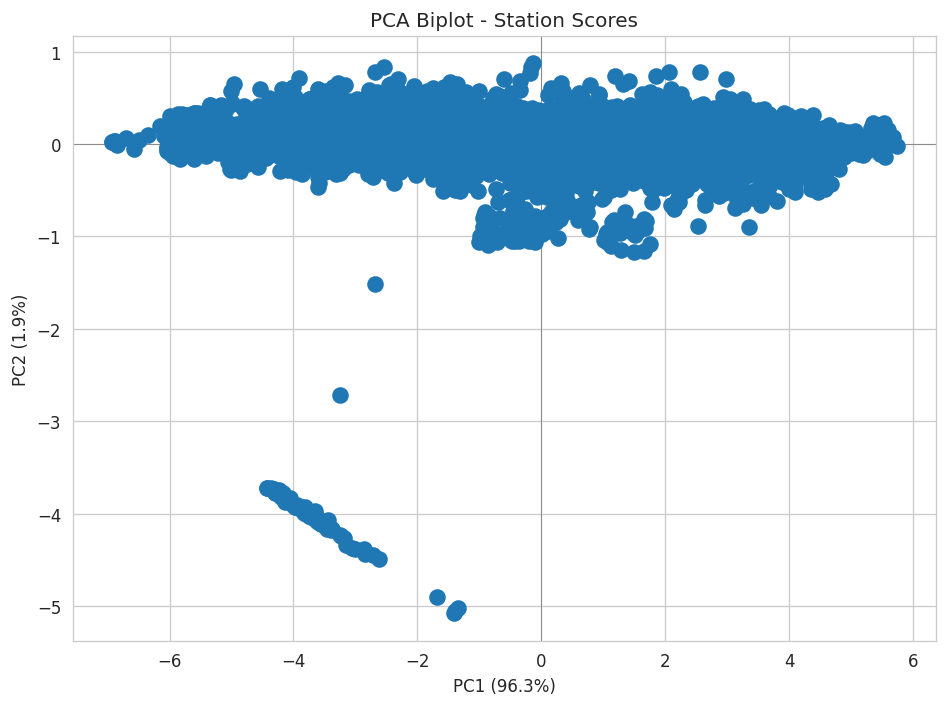

Saved: notebooks/figures/pca_biplot.png


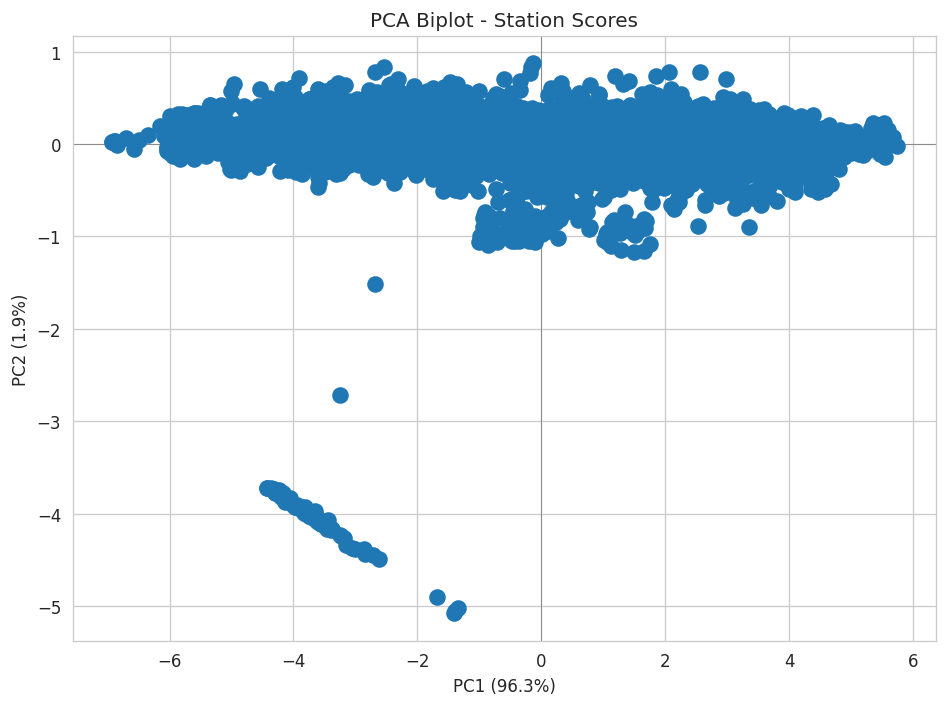

In [18]:
scores = pca_full.transform(normalized)

# Distinct color per station
station_colors = {
    "greenwich": "#e6194b",
    "cavendish": "#3cb44b",
    "north_rustico": "#4363d8",
    "stanhope": "#f58231",
    "stanley_bridge": "#911eb4",
    "tracadie": "#42d4f4",
}

fig, ax = plt.subplots(figsize=(8, 6))
for i, station in enumerate(matrix.columns):
    color = station_colors.get(station, None)
    ax.scatter(scores[i, 0], scores[i, 1], s=120, zorder=5, color=color, label=station, edgecolors="white", linewidth=0.5)
    ax.annotate(station, (scores[i, 0], scores[i, 1]), textcoords="offset points", xytext=(5, 5), fontsize=9, color=color)

ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA Biplot - Station Scores")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "pca_biplot.png", bbox_inches="tight")
display(Image(filename=str(FIGURES_DIR / "pca_biplot.png")))
print("Saved: notebooks/figures/pca_biplot.png")


## 6. Hierarchical Clustering

Stations clustered by temperature correlation to identify redundancy groups.


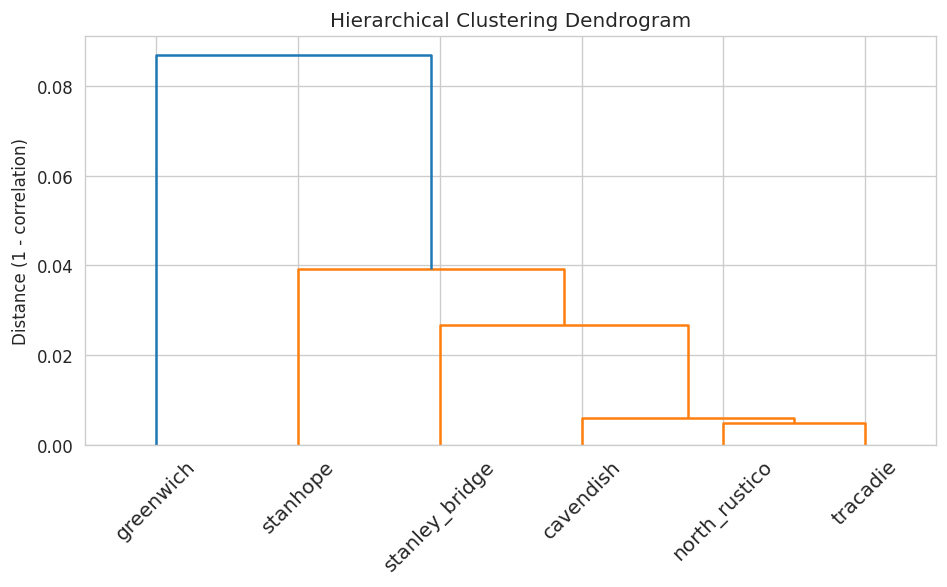

Saved: notebooks/figures/clustering_dendrogram.png


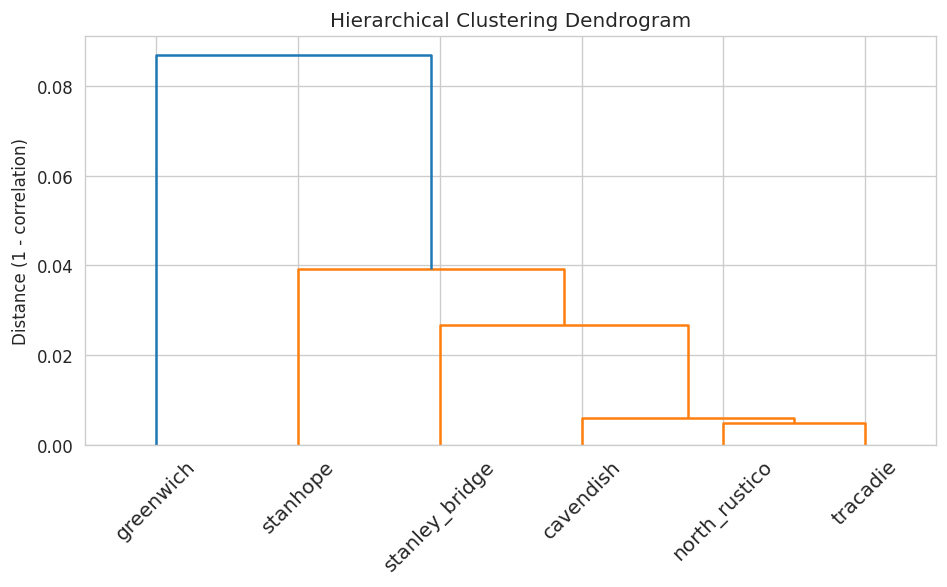

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

corr = matrix.corr()
distance = 1 - corr
dist_array = squareform(distance.values, checks=False)

link = linkage(dist_array, method="average")

fig, ax = plt.subplots(figsize=(8, 5))
dendrogram(link, labels=list(matrix.columns), ax=ax, leaf_rotation=45)
ax.set_ylabel("Distance (1 - correlation)")
ax.set_title("Hierarchical Clustering Dendrogram")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "clustering_dendrogram.png", bbox_inches="tight")
display(Image(filename=str(FIGURES_DIR / "clustering_dendrogram.png")))
print("Saved: notebooks/figures/clustering_dendrogram.png")


In [20]:
cluster_order = cluster_station_order(matrix)
print("Cluster assignments:")
for entry in cluster_order:
    print(f"  {entry}")

corr = pairwise_station_correlation(matrix).fillna(0.0)
dist = 1 - corr
print("\nPairwise distance matrix:")
print(dist.round(3).to_string())


Cluster assignments:
  stanhope
  tracadie
  cavendish
  north_rustico
  stanley_bridge
  greenwich

Pairwise distance matrix:
station         cavendish  greenwich  north_rustico  stanhope  stanley_bridge  tracadie
station                                                                                
cavendish           0.000      0.093          0.006     0.033           0.028     0.006
greenwich           0.093      0.000          0.086     0.095           0.102     0.058
north_rustico       0.006      0.086          0.000     0.035           0.026     0.005
stanhope            0.033      0.095          0.035     0.000           0.057     0.031
stanley_bridge      0.028      0.102          0.026     0.057           0.000     0.026
tracadie            0.006      0.058          0.005     0.031           0.026     0.000


## 7. Redundancy Analysis

Combining PCA, clustering, and benchmarking against the Stanhope reference to identify redundant stations.


In [21]:
try:
    benchmark = benchmark_to_stanhope(matrix, reference_station="stanhope")
    print("Benchmark results:")
    print(benchmark.to_string(index=False))
except ValueError as e:
    print(f"Stanhope benchmark skipped: {e}")
    print("Using inter-station metrics only.")
    benchmark = None


Benchmark results:
       station reference_station  overlap_count  mean_abs_diff  correlation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [22]:
if benchmark is not None and len(benchmark) > 0:
    recommendations = build_station_recommendations(
        benchmark,
        pca_loadings=loadings,
        cluster_order=cluster_order,
    )
    print("Station Recommendations:")
    print(recommendations.to_string(index=False))
else:
    print("Cannot build recommendations without benchmark.")
    recommendations = None


Station Recommendations:
       station reference_station recommendation  risk_probability  ci_lower  ci_upper risk_band                                                                                                    evidence                                                                                                                                                                                                                                                                                  assumptions                                                limitations
     cavendish          stanhope         remove          0.121140  0.012887  0.288408       low benchmark correlation=0.967; uncertainty=low (0.01-0.29); pca=[PC1=0.414, PC2=-0.168]; cluster=position 3/6 Distributional uncertainty is estimated with scipy.stats.gaussian_kde over observation-derived station-reference divergence samples; when benchmark fixtures omit raw observations, a documented synthetic distribution is gene

## 8. Uncertainty Quantification

Risk probabilities and confidence intervals for station removal.


Uncertainty Quantification (KDE-based risk):
       station reference_station  risk_probability  ci_lower  ci_upper risk_band                                                                                                                                                                                                                                                                                  assumptions                                                limitations
     cavendish          stanhope          0.121140  0.012887  0.288408       low Distributional uncertainty is estimated with scipy.stats.gaussian_kde over observation-derived station-reference divergence samples; when benchmark fixtures omit raw observations, a documented synthetic distribution is generated from mean difference, correlation, and overlap support. Sample support is adequate for a coarse uncertainty bound.
     greenwich          stanhope          0.028022  0.000000  0.060345       low Distributional uncertain

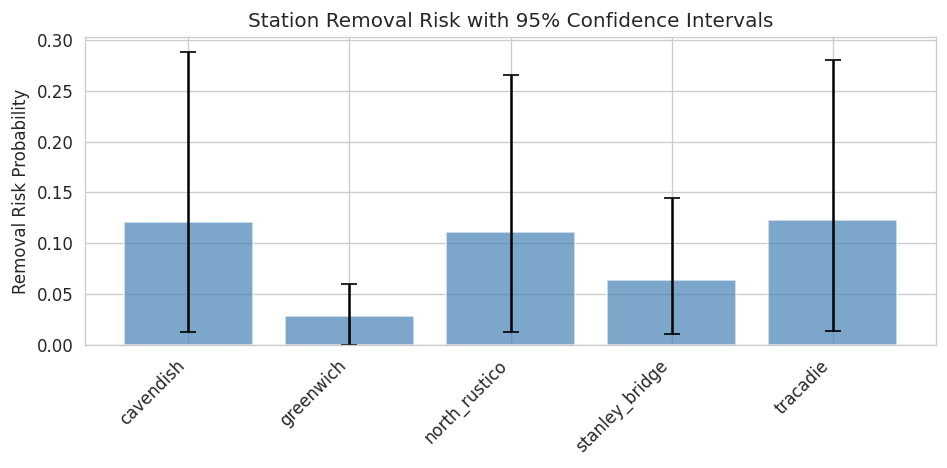

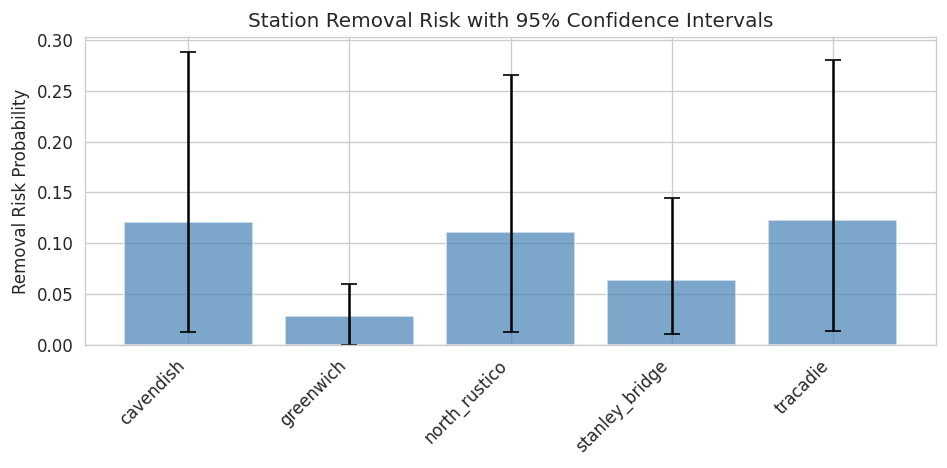

Saved: notebooks/figures/uncertainty_risk.png


In [23]:
from pea_met_network.uncertainty import quantify_station_removal_risk

if benchmark is not None and len(benchmark) > 0:
    uncertainty = quantify_station_removal_risk(benchmark)
    print("Uncertainty Quantification (KDE-based risk):")
    print(uncertainty.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    stations_plot = uncertainty["station"].tolist()
    risks = uncertainty["risk_probability"].tolist()
    ci_lo = uncertainty["ci_lower"].tolist()
    ci_hi = uncertainty["ci_upper"].tolist()

    x = range(len(stations_plot))
    ax.bar(x, risks, color="steelblue", alpha=0.7)
    yerr_lo = [r - lo for r, lo in zip(risks, ci_lo)]
    yerr_hi = [hi - r for r, hi in zip(risks, ci_hi)]
    ax.errorbar(x, risks, yerr=[yerr_lo, yerr_hi], fmt="none", c="black", capsize=5)
    ax.set_xticks(list(x))
    ax.set_xticklabels(stations_plot, rotation=45, ha="right")
    ax.set_ylabel("Removal Risk Probability")
    ax.set_title("Station Removal Risk with 95% Confidence Intervals")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "uncertainty_risk.png", bbox_inches="tight")
    plt.show()
    display(Image(filename=str(FIGURES_DIR / "uncertainty_risk.png")))
    print("Saved: notebooks/figures/uncertainty_risk.png")
else:
    print("Uncertainty analysis requires benchmark data (skipped).")


# Conclusion

_TBD — fill in after review._
